This file is used to visualize the pickled q data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.set_option('mode.chained_assignment', None)
warnings.simplefilter("ignore", category=RuntimeWarning)
import re
import pickle
import struct
from datetime import datetime, timedelta

from os import fsdecode
import pathlib

import matplotlib
import matplotlib.dates as mdates
import matplotlib.gridspec as gs
import matplotlib.pyplot as plt
import numpy as np
import spiceypy as spice
import pandas as pd
import pycwt as wavelet
import scipy.integrate as integrate
import scipy.signal as signal
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1 import make_axes_locatable
from spiceypy.spiceypy import xf2eul
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import math as m

import random
import os
import math


In [2]:
filename = 'slopes_df.pkl'
picklefile = open(filename,'rb')
slopes_df = pickle.load(picklefile)

In [3]:
z_limit = 3
Rmin = 10
Rmax = 35

In [4]:
filtered_mhd = slopes_df[( (slopes_df['mhd_slopes'] != 0)  & (slopes_df['mhd_slopes'] != 10) & (slopes_df['mhd_slopes'] < 0 ) &(slopes_df['mhd_slopes'] > -3 )  ) & (np.abs(slopes_df['Z'])<z_limit)]
filtered_kinetic = slopes_df[( (slopes_df['kinetic_slopes'] != 0)  & (slopes_df['kinetic_slopes'] != 10) & (slopes_df['kinetic_slopes'] < 0 ) &(slopes_df['kinetic_slopes'] > -4 )  ) &(np.abs(slopes_df['Z'])<z_limit)]

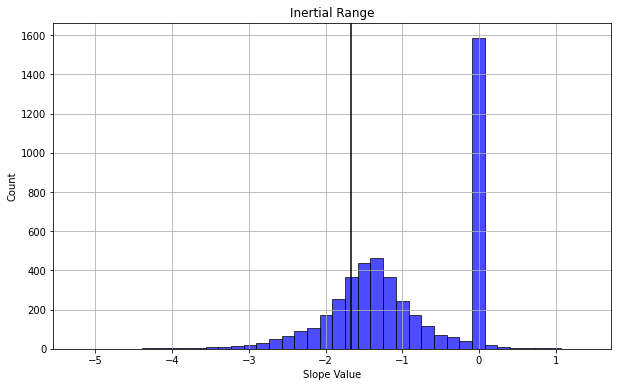

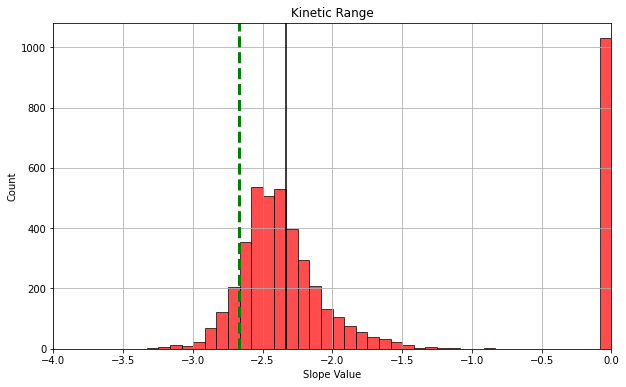

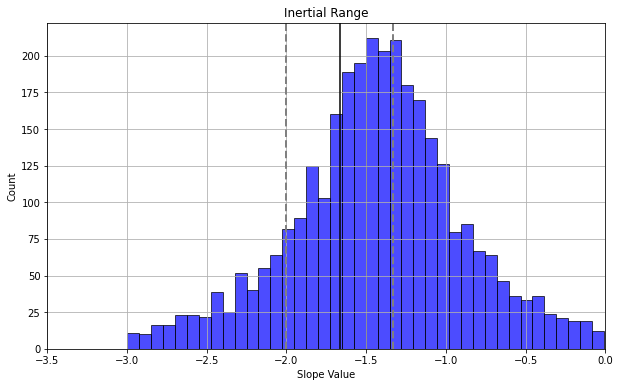

NameError: name 'combined_breaks_array' is not defined

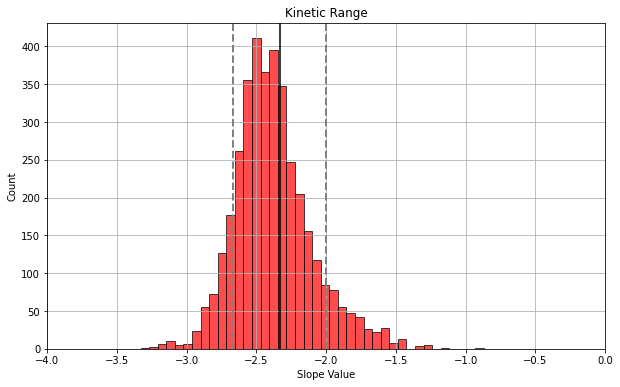

<Figure size 720x432 with 0 Axes>

In [ ]:
save=False
number_of_bins = 40
end = 'current'

combined_mhd_slopes = slopes_df['mhd_slopes'].tolist()
combined_kinetic_slopes = slopes_df['kinetic_slopes'].tolist()


plt.figure(figsize=(10, 6))
plt.hist(combined_mhd_slopes, bins=number_of_bins, alpha=0.7, color='blue', edgecolor='black')
plt.title('Inertial Range')
plt.xlabel('Slope Value')
plt.ylabel('Count')
plt.axvline(x=-5/3, color = 'black')
plt.grid()
if save:
    plt.savefig('dirty_mhd_hist_'+str(end)+'jpg', facecolor = 'white')
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(combined_kinetic_slopes, bins=number_of_bins, alpha=0.7, color='red', edgecolor='black')
plt.xlim(-3,0)
plt.title('Kinetic Range')
plt.xlabel('Slope Value')
plt.ylabel('Count')
plt.axvline(x=-7/3, color = 'black')
plt.axvline(x=-8/3, color = 'green', linewidth = 3, linestyle = '--')

plt.grid()
plt.xlim(-4,0)
if save:
    plt.savefig('dirty_kinetic_hist_'+str(end)+'jpg', facecolor = 'white')


filtered_mhd = [num for num in combined_mhd_slopes if num != 0 and num != 10 and num < 0 and num > -3]
filtered_kinetic = [num for num in combined_kinetic_slopes if num != 0 and num < 0 and num > -4]


plt.figure(figsize=(10, 6))
plt.hist(filtered_mhd, bins=number_of_bins, alpha=0.7, color='blue', edgecolor='black')
plt.title('Inertial Range')
plt.xlabel('Slope Value')
plt.ylabel('Count')
plt.axvline(x=-5/3, color = 'black')
plt.axvline(x = (-5/3)+(1/3),color = 'grey', linestyle = '--',linewidth = 2)
plt.axvline(x = (-5/3)-(1/3),color = 'grey', linestyle = '--',linewidth = 2)
plt.grid()
plt.xlim(-3.5,0)
if save:
    plt.savefig('clean_mhd_hist_'+str(end)+'jpg', facecolor = 'white')

plt.show()

plt.figure(figsize=(10, 6))
plt.hist(filtered_kinetic, bins=number_of_bins, alpha=0.7, color='red', edgecolor='black')
#plt.xlim(-4,0)
plt.title('Kinetic Range')
plt.xlabel('Slope Value')
plt.ylabel('Count')
plt.axvline(x=-7/3, color = 'black')
plt.axvline(x=-8/3, color = 'grey',linewidth = 2, linestyle = '--')
plt.axvline(x=-6/3, color = 'grey',linewidth = 2, linestyle = '--')
plt.grid()
plt.xlim(-4,0)
if save:
    plt.savefig('clean_kinetic_hist_'+str(end)+'jpg', facecolor = 'white')

plt.figure(figsize=(10, 6))
plt.hist(combined_breaks_array, bins=number_of_bins, alpha=0.7, color='orange', edgecolor='black')
#plt.xlim(-4,0)
plt.title('Break Frequencies')
plt.xlabel('frequency [Hz]')
plt.ylabel('Count')
#plt.axvline(x=-7/3, color = 'black')
plt.grid()
plt.xscale('log')
if save:
    plt.savefig('breaks_hist_'+str(end)+'jpg', facecolor = 'white')

ratio = [i/j for i,j in  zip(combined_breaks_array, combined_gyros_array)]
plt.figure(figsize=(10, 6))
plt.hist(ratio, bins=number_of_bins, alpha=0.7, color='orange', edgecolor='black')
#plt.xlim(-4,0)
plt.title('Break Frequencies/Gyro Ratio')
plt.xlabel('Ratio')
plt.ylabel('Count')
#plt.axvline(x=-7/3, color = 'black')
plt.grid()
if save:
    plt.savefig('breaks_ratio_hist_'+str(end)+'jpg', facecolor = 'white')
plt.figure(figsize=(10, 6))
plt.hist(combined_thetas_array, bins=number_of_bins, alpha=0.7, color='orange', edgecolor='black')
plt.axvline(x = 90, color = 'black')
#plt.xlim(-4,0)
plt.title('Angle between v and B')
plt.xlabel(r'${\theta_{vB}}$ [Deg]')
plt.ylabel('Count')
#plt.axvline(x=-7/3, color = 'black')
plt.grid()
if save:
    plt.savefig('theta_hist_'+str(end)+'jpg', facecolor = 'white')
print(combined_mhd_slopes)


CategoricalIndex([ 8.0, 10.0, 12.0, 14.0, 16.0, 18.0, 20.0, 22.0, 24.0, 26.0,
                  28.0, 30.0, 32.0, 34.0, 36.0],
                 categories=[8.0, 10.0, 12.0, 14.0, ..., 30.0, 32.0, 34.0, 36.0], ordered=True, dtype='category', name='r_bin')
5.0500000000000004e-15
-0.592


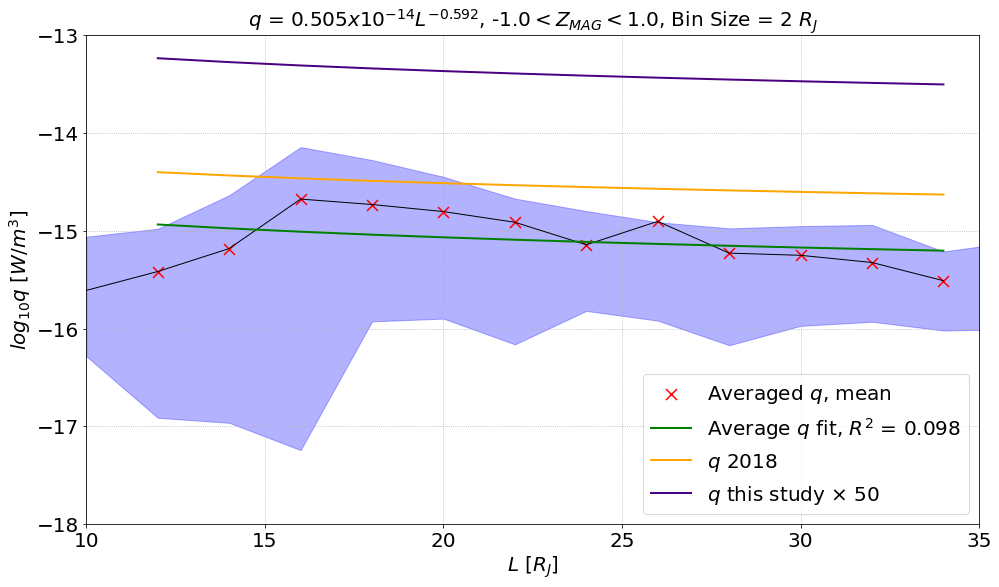

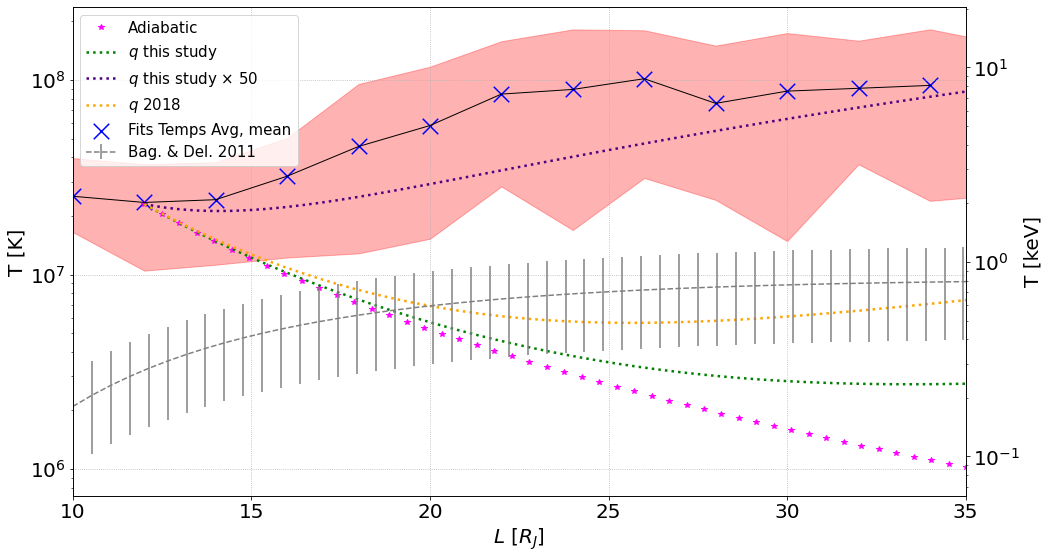

593
0.36071428571428577


In [ ]:
z_limits = [1]
bin_sizes = [2]
binsize_plot = [2]
filename = 'q_data_for_plots.pkl'
picklefile = open(filename,'rb')
sorted_q_dfs_desc_R = pickle.load(picklefile)
filename = 'combined_fits_df_from_wang_2024.pkl'
picklefile = open(filename,'rb')
combined_fit_dfs = pickle.load(picklefile)

end = 'current'
save = False

for z_lim in z_limits:
    sorted_q_dfs_desc_R = sorted_q_dfs_desc_R.iloc[np.where(np.abs(sorted_q_dfs_desc_R['mean_Z']) < z_lim )].dropna()
    def _t_eq_2(L, L0, T0, n_0, gamma, v_0, alpha, q_0, s):
        T = []
        T_adiabatic = []
        L_max = np.max(L)
        L_values = np.linspace(L0, L_max, len(L)) 
        k_b = 1.38e-23
        sigma = 2*gamma/3
        R_j = 7.14e7
        omega = (2/3)*(q_0*R_j/(k_b*n_0*v_0))
        lam = s-gamma-alpha
        for L in L_values:

            integration = (omega/(L0**(-sigma)))*(L/L0)**(sigma)*((L**(lam-sigma+1)/(lam-sigma+1)) - (L0**(lam-sigma+1)/(lam-sigma+1))) 
            
            L_over_L0 = L/L0
            T_value = T0*L_over_L0**(sigma) + integration
            T_value_adiabatic = T0*L_over_L0**(sigma) #+ c1 * L_over_L0**(-2*beta/3)*integration[0]
            T.append(T_value)
            T_adiabatic.append(T_value_adiabatic)
        return T, T_adiabatic
    def _temp_dist(RRR):    
        a1 = -0.116
        a2= 2.14
        a3= -2.05
        a4= 0.491
        a5= 0.126
        amu=22
        rrr=np.log10(RRR/6)
        h=a1+a2*rrr+a3*rrr**2.+a4*rrr**3.+a5*rrr**4.

        H=10.**h

        T=amu*(H/0.64)**2.

        T_kelvin = T*11606
        return T_kelvin


    def extract_base_exponent_scientific(number):
        exponent = int(np.log10(number))
        base = number / (10 ** exponent)
        return base, exponent


    array_to_be_averaged = sorted_q_dfs_desc_R

    j=0
    for bin_size in bin_sizes:
        R_values = array_to_be_averaged['mean_R']

        q_values_mhd = array_to_be_averaged['q_mhd'].iloc[np.where(array_to_be_averaged['q_mhd'] != 100)]
        q_values_kaw = array_to_be_averaged['q_kaw'].iloc[np.where(array_to_be_averaged['q_kaw'] != 100)]
        q_values_mean = array_to_be_averaged['q_mean_whole_range']
        


        binned_q_array_mhd = []
        binned_q_array_kaw = []
        binned_q_array_mean = []
        binned_temp_array= []
        binned_q_array_mean_plot = []
        binned_temp_array_plot= []

        binned_R_array = [] 
        binned_R_array_plot = []
        binned_q_array_mean_left = []
        
        binned_R_array_left = []

        binned_q_mean_std = []
        binned_temp_std = []
        binned_temp_std_plot=[]


        factor = bin_size
        factor_plot = binsize_plot[j]
        j+=1
        start=6
        right_start=12
        end_L = 36

        Rs = np.arange(right_start,end_L, factor)
        Rs_full = np.arange(start,end_L, factor_plot)
        
        Rs_left = np.arange(start,right_start+2, 2)

        fits_df_limited = combined_fit_dfs.iloc[np.where( (np.abs(combined_fit_dfs['Z_MAG']) < z_lim))]

        R_spher_here = fits_df_limited['  "R"']
        Z_mag_here =fits_df_limited['Z_MAG']
        R_cyl_here = np.sqrt(R_spher_here**2-Z_mag_here**2)
        for i in Rs:
            L = i
            average_L = i
            constrained_array_mhd = array_to_be_averaged.iloc[np.where(   (array_to_be_averaged['mean_R'] > (L - factor/2))  &   (array_to_be_averaged['mean_R'] < (L+factor/2)) & (array_to_be_averaged['q_mhd'] != 100))]
            constrained_array_kaw =    array_to_be_averaged.iloc[np.where(   (array_to_be_averaged['mean_R'] > (L-factor/2))  &   (array_to_be_averaged['mean_R'] < (L+factor/2)) & (array_to_be_averaged['q_kaw'] != 100))]
            constrained_array_mean =    array_to_be_averaged.iloc[np.where(   (array_to_be_averaged['mean_R'] > (L-factor/2))  &   (array_to_be_averaged['mean_R'] < (L+factor/2)))]
            constrained_array_temp =  fits_df_limited.iloc[np.where(   (R_cyl_here > (L-factor/2))  &   (R_cyl_here < (L+factor/2)))]


            average_value_mhd = np.nanmean(constrained_array_mhd['q_mhd'])
            average_value_kaw = np.nanmean(constrained_array_kaw['q_kaw'])
            average_value_mean = np.nanmean(constrained_array_mean['q_mean_whole_range'])
            std_q = np.nanstd(constrained_array_mean['q_mean_whole_range'], ddof=1)
            average_value_temp = np.nanmean(constrained_array_temp['    "T"'])
            std_temp = np.nanstd(constrained_array_temp['    "T"']*11606, ddof=1)
            
            
            binned_q_array_mhd.append(average_value_mhd)
            binned_q_array_kaw.append(average_value_kaw)
            binned_q_array_mean.append(average_value_mean)
            binned_temp_array.append(average_value_temp)

            binned_R_array.append(average_L)

            binned_q_mean_std.append(std_q)
            binned_temp_std.append(std_temp)
            
        for i in Rs_full:
            L = i
            average_L = i    
            constrained_array_mean_plot =    array_to_be_averaged.iloc[np.where(   (array_to_be_averaged['mean_R'] > (L-factor/2))  &   (array_to_be_averaged['mean_R'] < (L+factor/2)))]
            constrained_array_temp_plot =  fits_df_limited.iloc[np.where( (   R_cyl_here > (L-factor/2))  &   (R_cyl_here< (L+factor/2)))]

            average_value_mean_plot = np.nanmean(constrained_array_mean_plot['q_mean_whole_range'])
            average_value_temp_plot = np.nanmean(constrained_array_temp_plot['    "T"'])
            std_temp = np.nanstd(constrained_array_temp_plot['    "T"']*11606, ddof=1)
            
            binned_q_array_mean_plot.append(average_value_mean_plot)
            binned_temp_array_plot.append(average_value_temp_plot)
            
            
            binned_R_array_plot.append(average_L)
            binned_temp_std_plot.append(std_temp)
            
        for i in Rs_left:
            L = i
            average_L = i    
            constrained_array_mean_left =    array_to_be_averaged.iloc[np.where(   (array_to_be_averaged['mean_R'] > (L-factor/2))  &   (array_to_be_averaged['mean_R'] < (L+factor/2)))]
            constrained_array_temp_left =  fits_df_limited.iloc[np.where(   (R_cyl_here > (L-factor/2))  &   (R_cyl_here < (L+factor/2)) )]

            average_value_mean_left = np.nanmean(constrained_array_mean_left['q_mean_whole_range'])
            average_value_temp_left = np.nanmean(constrained_array_temp_left['    "T"'])
            
            binned_q_array_mean_left.append(average_value_mean_left)
            
            binned_R_array_left.append(average_L)


        both_averages = [binned_R_array,binned_q_array_mhd,binned_q_array_kaw,binned_q_array_mean, binned_temp_array,binned_q_mean_std,binned_temp_std]
        both_averages_plot = [binned_R_array_plot, binned_q_array_mean_plot, binned_temp_array_plot,binned_temp_std_plot]
        both_averages_left = [binned_R_array_left, binned_q_array_mean_left]
        
        df2 = np.asarray(both_averages)
        df_combined = np.asarray(both_averages)
        df3 = np.asarray(both_averages_plot)
        df4 = np.asarray(both_averages_left)

        X_mean = np.log10(df2[0][np.where((df_combined[0] > 0) & (df_combined[3] >0)) ].reshape(-1,1))
        X_mean_plot = np.log10(df3[0][np.where((df3[0] > 0) & (df3[1] >0)) ].reshape(-1,1))
        X_mean_left = np.log10(df4[0][np.where((df4[0] > 0) & (df4[1] >0)) ].reshape(-1,1))


        X_mean_all = np.log10(np.asarray(sorted_q_dfs_desc_R['mean_R'].iloc[np.where((sorted_q_dfs_desc_R['mean_R'] < 40 ) & (sorted_q_dfs_desc_R['mean_R'] > 10))].dropna()).reshape(-1,1))



        Y_mean = np.log10(df_combined[3][np.where((df_combined[0] > 0) & (df_combined[3] >0)) ].reshape(-1,1))
        Y_mean_plot = np.log10(df3[1][np.where((df3[0] > 0) & (df3[1] >0)) ].reshape(-1,1))
        Y_mean_left = np.log10(df4[1][np.where((df4[0] > 0) & (df4[1] >0)) ].reshape(-1,1))
        
        
        
        
        Y_mean_all = np.log10(np.asarray(sorted_q_dfs_desc_R['q'].iloc[np.where((sorted_q_dfs_desc_R['mean_R'] < 40 ) & (sorted_q_dfs_desc_R['mean_R'] > 10))].dropna()).reshape(-1,1))

        Y_kaw = np.log10(df_combined[2][np.where((df_combined[0] > 0) & (df_combined[2] >0)) ].reshape(-1,1))





        model_mhd = LinearRegression()

        model_mhd_all = LinearRegression()

        model_kaw = LinearRegression()

        model_kaw_all = LinearRegression()
        
        model_mean = LinearRegression()
        model_mean.fit(X_mean,Y_mean)

        model_mean_all = LinearRegression()
        model_mean_all.fit(X_mean_all,Y_mean_all)
        
        model_mean_left = LinearRegression()
        model_mean_left.fit(X_mean_left,Y_mean_left)


  
        
        mean_intercept = 10**model_mean.intercept_
        mean_slope = model_mean.coef_[0]
        
        mean_intercept_all = 10**model_mean_all.intercept_
        mean_slope_all = model_mean_all.coef_[0]

        mean_intercept_left = 10**model_mean_left.intercept_
        mean_slope_left = model_mean_left.coef_[0]

        y_pred_mean = model_mean.predict(X_mean)
        y_pred_mean_all = model_mean_all.predict(X_mean_all)
        y_pred_mean_left = model_mean_left.predict(X_mean_left)
        
        
    
        r2_q_all = r2_score(Y_mean,y_pred_mean)
        
        r2_q_all_left = r2_score(Y_mean_left,y_pred_mean_left)

        

        mean_base, mean_exponent = extract_base_exponent_scientific(mean_intercept)
        
        mean_base_left, mean_exponent_left = extract_base_exponent_scientific(mean_intercept_left)
   
        
        mean_base_value = mean_base[0]
        mean_slope_value = mean_slope[0]
        
        mean_base_value_left = mean_base_left[0]
        mean_slope_value_left = mean_slope_left[0]

        q_std = df_combined[-2][np.where((df_combined[0] > 0) & (df_combined[3] >0)) ].reshape(-1,1)

        yerr_log = q_std.ravel() / ((df_combined[3][np.where((df_combined[0] > 0) & (df_combined[3] >0)) ].reshape(-1,1)).ravel() * np.log(10)) 



        fig,ax = plt.subplots(figsize=(16, 9),facecolor='white')

        trouble_color= 'indigo'

        size=3


        df = sorted_q_dfs_desc_R.iloc[np.where((sorted_q_dfs_desc_R['mean_R'] < 10**X_mean_all.max() ) & (sorted_q_dfs_desc_R['mean_R'] > 10**X_mean_all.min()))]
        df['r_bin'] = pd.cut(df['mean_R'], bins=np.arange(7, 39, 2))  # 2 unit bin width

        percentiles = np.log10(df.groupby('r_bin')['q_mean_whole_range'].quantile([0.05,0.1, 0.25, 0.5, 0.75, 0.9,0.95]).unstack())

        bin_centers = percentiles.index.map(lambda x: x.mid)
        ax.fill_between(bin_centers, percentiles[0.1], percentiles[0.9],color= 'blue',alpha=0.3)

        ax.scatter(10**X_mean, Y_mean,s=40*size, color='red', marker='x', label = r'Averaged $q$, mean')

        
        q_0_2018 = 1.4*10**(-14)
        s_2018 = -0.507

     
        ax.plot(10**X_mean_plot, Y_mean_plot, color='black', linewidth=1)
        ax.plot(10**X_mean, y_pred_mean, color='green', linewidth=2, label=r'Average $q$ fit, $R^2$ = ' + str(round(r2_q_all, 3)))
        ax.plot(10**X_mean, np.log10(q_0_2018*(10**X_mean)**s_2018), color='orange', linewidth=2, label=r'$q$ 2018')
        ax.plot(10**X_mean, np.log10(50)+y_pred_mean, color=trouble_color, linewidth=2, label=r'$q$ this study $\times$ 50 ')

        chy_rs = np.asarray([21, 23, 25, 27, 29, 31, 33, 35])
        chy_means = np.asarray([8.87734489e-14 ,5.00541703e-14, 3.04250077e-14, 2.64508592e-14, 3.67429033e-14, 3.86285420e-14, 3.56174713e-14, 2.48910274e-14])
        chy_meds = np.asarray([5.34308950e-14, 3.31215418e-14, 5.26261690e-14, 4.72190379e-14,2.84037275e-14, 3.20764621e-14, 2.83800051e-14, 2.48134928e-14])



       ax.set_title(r'$q$ = ' + str(round(mean_base_value, 3))+ r"$ x 10^{"+ str(round(mean_exponent,3))+r'}$'+  r'$L^{'+str(round(mean_slope_value,3))+ r'}$, ' + str(round(sorted_q_dfs_desc_R['mean_Z'].min(), 2)) + r'$ < Z_{MAG} < $' + str(round(sorted_q_dfs_desc_R['mean_Z'].max(), 2))+ r', Bin Size = ' +str(factor) +r' $R_J$', fontsize = 20)


        ax.set_ylabel(r'$log_{10}q$ $[W/m^3]$', fontsize = 20)
        ax.set_xlabel(r'$L$ $[R_J]$',fontsize=20)
        ax.set_ylim(-18,-13)
        ax.set_xlim(10,35)
        ax.tick_params(axis='both', labelsize=20)
        ax.legend(loc = 'lower right', fontsize=20)
        plt.grid(True,alpha = 1,ls = ":")

        save = True
        if save:
            plt.savefig('/home/mtfranciscovich/Juno-codes/FOR_PAPER/mean_test_q_binsize' + str(bin_size)+'_'+str(end)+'_zlim_' +str(z_lim)+'_1222025.jpg', facecolor = 'white',dpi=300)
        


    
        T0 = 2.3e7
        L0 = 12
        number_of_R = 50



      
        
        q_0_mean = round(mean_base_value, 3)*10**round(mean_exponent,3)
        s_mean = round(mean_slope_value,3)
        



        L = np.linspace(L0,end_L,number_of_R)

        L_emp = np.linspace(10,end_L,number_of_R)

        n_0 = (6.246*10**5)*10**6
        gamma = -4.362
        v_0 = (.674*10**-2)*10**3
        alpha = 2.616



        q_0 = q_0_mean
        s = s_mean
        beta = gamma



        
        result_mean_no_filter_2 =_t_eq_2(L,L0, T0, n_0, gamma, v_0, alpha, q_0, s)
        result_mean_no_filter_times_10 =_t_eq_2(L,L0, T0, n_0, gamma, v_0, alpha, q_0*50, s)

        result_2018 = _t_eq_2(L,L0, T0, n_0, gamma, v_0, alpha, q_0_2018, s_2018)

        empirical = _temp_dist(L_emp)
        error =0.5 * empirical

        fig,ax = plt.subplots(figsize=(16, 9),facecolor='white')
        ax.plot(L, result_mean_no_filter_2[1], c = 'magenta', linestyle = '',marker = '*', label = 'Adiabatic')

        ax.plot(L, result_mean_no_filter_2[0], color = 'green', label = r'$q$ this study',ls = ':', linewidth=2.5)
        ax.plot(L, result_mean_no_filter_times_10[0], color = trouble_color, label = r'$q$ this study $\times$ 50',ls = ':', linewidth=2.5)
        ax.plot(L, result_2018[0], color = 'orange', label = r'$q$ 2018',ls = ':', linewidth=2.5)



        

        fits_df_limited['R_cyl'] = R_cyl_here
        fits_df_limited['T_k'] = fits_df_limited['    "T"']*11606


        df = fits_df_limited.dropna()
        df['r_bin'] = pd.cut(df['R_cyl'], bins=np.arange(7, 39, 2))  # 2 unit bin width

        percentiles = df.groupby('r_bin')['T_k'].quantile([0.05,0.1, 0.25, 0.5, 0.75, 0.9,0.95]).unstack()

        bin_centers = percentiles.index.map(lambda x: x.mid)

        print(bin_centers)
        ax.fill_between(bin_centers, percentiles[0.1], percentiles[0.9],color= 'red',alpha=0.3)

        t_std = df3[-1]

        yerr_log = t_std.ravel() / (df3[2].ravel()* np.log(10))

        ax.scatter(df3[0], df3[2]*11606, color = 'blue', label = 'Fits Temps Avg, mean', s=80*size, marker = 'x') 
        
        
        ax2 = plt.twinx(ax)
        ax2.scatter(df3[0], df3[2], color = 'blue', s=80*size, marker = 'x')

        ax.plot(df3[0], df3[2]*11606, color = 'k', linewidth=1) 

        ax.errorbar(L_emp, empirical,yerr = error, linestyle = '--', color = 'grey', label = 'Bag. & Del. 2011',alpha=1)
        ax.set_yscale('log')
        ax2.set_yscale('log')
        ax.set_xlim(L.min(),L.max())
        ax2.set_xlim(L.min(),L.max())
        ax.set_xlabel(r'$L$ $[R_J]$',fontsize=20)
        ax.set_ylabel(r'T [K]',fontsize=20)
        ax2.set_ylabel(r'T [keV]',fontsize=20)

        
        ax.legend(loc = 'upper left', fontsize=15)
        
        ax.set_xlim(10,35)
        ax2.set_xlim(10,35)
        ymin, ymax = ax.get_ylim()
        ax2.set_ylim((ymin/11606)/1000,(ymax/11606)/1000)
        ax.grid(True,alpha = 1,ls = ":")

        ax.tick_params(axis='both', labelsize=20)
        ax2.tick_params(axis='both', labelsize=20)

        print(q_0_mean)
        print(s)
        save = False
        if save:
            plt.savefig('/home/mtfranciscovich/Juno-codes/FOR_PAPER/mean_test_temp_binsize' + str(bin_size)+'_'+str(end)+'_zlim_' +str(z_lim)+'_1222025.jpg', facecolor = 'white',dpi=300)
        plt.show()

        print(len(np.log10(sorted_q_dfs_desc_R['q_mean_whole_range'].iloc[np.where((sorted_q_dfs_desc_R['mean_R'] < 10**X_mean_all.max() ) & (sorted_q_dfs_desc_R['mean_R'] > 10**X_mean_all.min()))])))
print(q_0_mean/q_0_2018)


2121 Data points

In [7]:
energy_df = sorted_q_dfs_desc_R

In [8]:
import matplotlib.colors as clrs

Index(['q', 'q_kaw', 'q_mhd', 'mean_R', 'mean_Z', 'mean_density', 'mean_vphi',
       'mean_b_perp', 'avg_times', 'local_times', 'kperps', 'mean_deltabperp3',
       'sintheta', '|v|', 'freq_mhd', 'q_mean_whole_range',
       'q_mean_whole_range_int'],
      dtype='object')


<ipython-input-9-bd0b1c0005b7>:65: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([10,20,30,40],size =25)


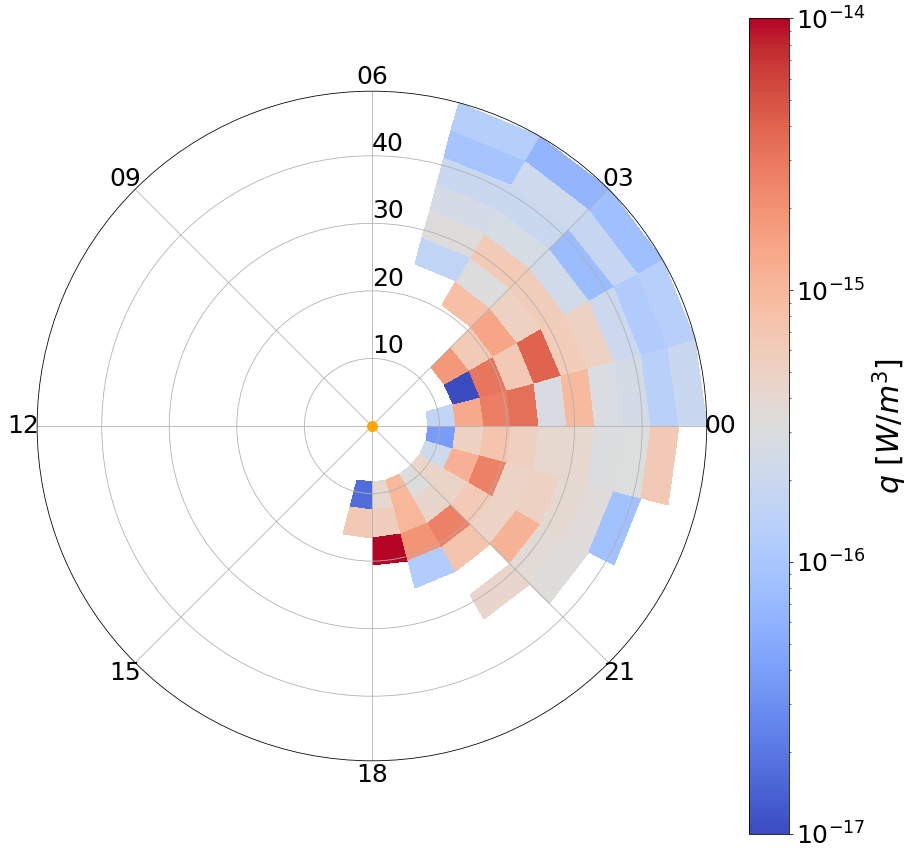

In [9]:



z_lim = 1

df = sorted_q_dfs_desc_R


print(df.columns)

Z = df['q_mean_whole_range']  


r = df['mean_R']  

thetas = (df['local_times']) * (90/6) 

thetas = thetas % 360  

local_time_rad = np.deg2rad(thetas)

n_theta_bins =  int(24*2**0)
n_radial_bins = int((r.max()/4)) 

r_edges = np.linspace(0, np.max(r), n_radial_bins + 1)

theta_edges = np.linspace(0, 2 * np.pi, n_theta_bins + 1)  
hist, theta_edges, r_edges = np.histogram2d(local_time_rad, r, bins=[theta_edges, r_edges], weights=Z)

bin_counts, _, _ = np.histogram2d(local_time_rad, r, bins=[theta_edges, r_edges])


avg_values = hist / bin_counts


theta_bin_centers = 0.5 * (theta_edges[:-1] + theta_edges[1:])
r_bin_centers = 0.5 * (r_edges[:-1] + r_edges[1:])

fig = plt.figure(figsize=(15, 15),facecolor = 'white')
ax = fig.add_subplot(111, projection='polar')
Theta, R = np.meshgrid(theta_bin_centers, r_bin_centers)


factor = 2

norm = clrs.LogNorm(10**(-17), 10**(-14))
absc = abs(avg_values)
c = ax.pcolormesh(Theta, R, avg_values.T, cmap='coolwarm', shading='auto', norm = norm)



cbar = fig.colorbar(c, ax=ax)
hour_labels = np.asarray(['00', '03', '06','09', '12', '15', '18', '21'])

cbar.ax.tick_params(labelsize = 25)
cbar.set_label(r'$q$ $[W/m^3]$', size = (30))



hour_angles = np.deg2rad(np.asarray([int(value) for value in hour_labels] )* 90/6)  

ax.set_xticks(hour_angles)

ax.set_xticklabels(hour_labels, size =25)
ax.plot(0, 0, 'o',color = 'orange', markersize=10)

ax.set_rlabel_position(90) 
ax.set_yticklabels([10,20,30,40],size =25)


plt.show()


<ipython-input-10-ca7afdc12e77>:65: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([10,20,30,40],size =25)


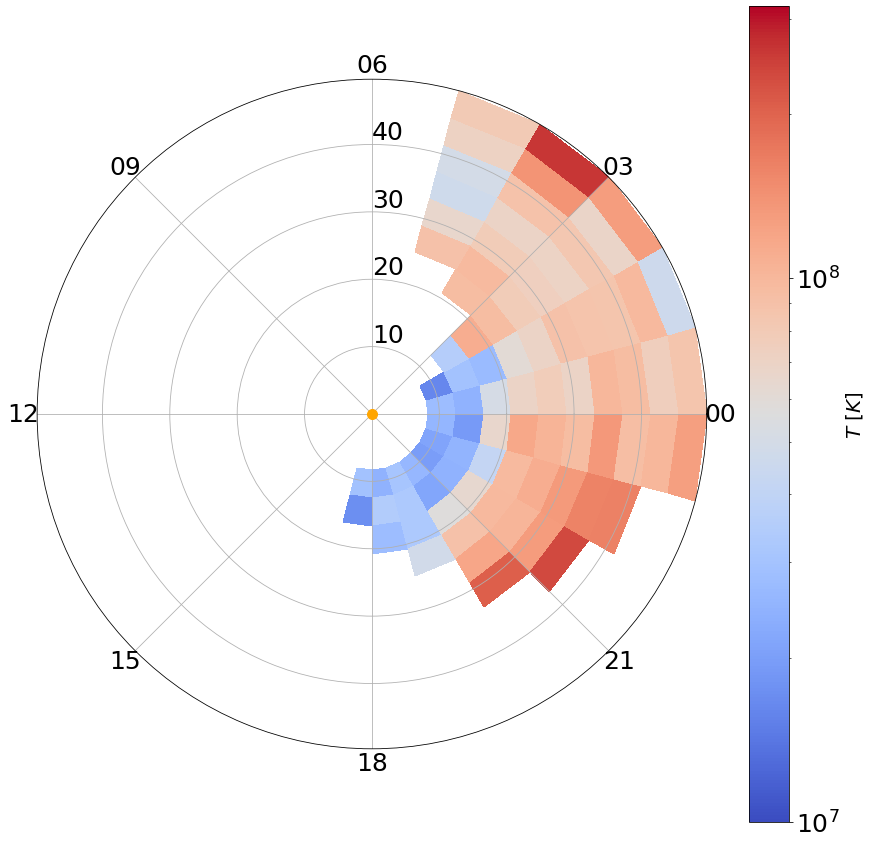

In [10]:



z_lim = 1
df = energy_df.iloc[np.where( (np.abs(energy_df['mean_Z']) < z_lim) & (energy_df['mean_R'] < 50) & (energy_df['mean_R'] > 10))]


df = combined_fit_dfs.iloc[np.where( (np.abs(combined_fit_dfs['Z_MAG']) < z_lim))]





Z = df['    "T"']*11606


r = df['  "R"']  
thetas = (df[' "LT"']) * (90/6)
thetas = thetas % 360 

local_time_rad = np.deg2rad(thetas)

n_theta_bins =  int(24*2**0) 
n_radial_bins = int((r.max()/4))  

r_edges = np.linspace(0, np.max(r), n_radial_bins + 1)

theta_edges = np.linspace(0, 2 * np.pi, n_theta_bins + 1) 
hist, theta_edges, r_edges = np.histogram2d(local_time_rad, r, bins=[theta_edges, r_edges], weights=Z)

bin_counts, _, _ = np.histogram2d(local_time_rad, r, bins=[theta_edges, r_edges])

avg_values = hist / bin_counts


theta_bin_centers = 0.5 * (theta_edges[:-1] + theta_edges[1:])
r_bin_centers = 0.5 * (r_edges[:-1] + r_edges[1:])

fig = plt.figure(figsize=(15, 15),facecolor = 'white')
ax = fig.add_subplot(111, projection='polar')
Theta, R = np.meshgrid(theta_bin_centers, r_bin_centers)


factor = 2

norm = clrs.LogNorm(10**7, 10**8.5)
absc = abs(avg_values)
c = ax.pcolormesh(Theta, R, avg_values.T, cmap='coolwarm', shading='auto', norm = norm)



cbar = fig.colorbar(c, ax=ax)
hour_labels = np.asarray(['00', '03', '06','09', '12', '15', '18', '21'])

cbar.ax.tick_params(labelsize = 25)
cbar.set_label(r'$T$ $[K]$', size = (20))



hour_angles = np.deg2rad(np.asarray([int(value) for value in hour_labels] )* 90/6)  

ax.set_xticks(hour_angles)

ax.set_xticklabels(hour_labels, size =25)
ax.plot(0, 0, 'o',color = 'orange', markersize=10)

ax.set_rlabel_position(90)  
ax.set_yticklabels([10,20,30,40],size =25)


plt.show()
